In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# Data Preprocessing Libraries
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

from sklearn.model_selection import GridSearchCV

In [4]:
df = pd.read_excel("C:/Users/lenovo/Downloads/Advanced_Student_Placement_Dataset_5000_Balanced.xlsx")

In [5]:
df.head()

,Student_ID,Student_Name,Gender,Age,State,10th_Percentage,12th_Percentage,Degree_Percentage,Degree_Stream,Specialization,...,Hackathons,Attendance_Percentage,Leadership,Extracurricular,Mock_Interview_Score,Resume_Score,English_Proficiency,Placement_Training_Hours,Placement_Status,Expected_Salary_LPA
0,STU00001,Sai Mishra,Male,23,PB,66,99,64,BBA,HR,...,3,85,No,Cultural,66,63,Average,140,Placed,14.44
1,STU00002,Aditi Das,Male,24,GJ,70,62,79,B.Com,Marketing,...,1,71,No,Cultural,100,57,Average,86,Placed,11.18
2,STU00003,Ishita Khan,Female,20,DL,75,62,91,B.Com,Computer Science,...,3,95,Yes,NaN,98,43,Average,145,Placed,15.98
3,STU00004,Harshit Patel,Female,23,TN,82,63,68,BBA,HR,...,6,83,Yes,NSS,57,47,Poor,27,Placed,12.28
4,STU00005,Riya Nair,Female,20,TN,64,56,90,B.Tech,Data Science,...,4,91,Yes,NaN,80,41,Poor,82,Placed,15.08


In [6]:
df.shape

(5000, 31)

In [7]:
df.columns

Index(['Student_ID', 'Student_Name', 'Gender', 'Age', 'State',
       '10th_Percentage', '12th_Percentage', 'Degree_Percentage',
       'Degree_Stream', 'Specialization', 'CGPA', 'Aptitude_Score',
       'Coding_Score', 'Communication_Skills', 'Technical_Skills',
       'Logical_Reasoning', 'Soft_Skills_Rating', 'Real_Life_Projects',
       'Internship_Experience', 'Work_Experience_Months', 'Certifications',
       'Hackathons', 'Attendance_Percentage', 'Leadership', 'Extracurricular',
       'Mock_Interview_Score', 'Resume_Score', 'English_Proficiency',
       'Placement_Training_Hours', 'Placement_Status', 'Expected_Salary_LPA'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Student_ID                5000 non-null   object 
 1   Student_Name              5000 non-null   object 
 2   Gender                    5000 non-null   object 
 3   Age                       5000 non-null   int64  
 4   State                     5000 non-null   object 
 5   10th_Percentage           5000 non-null   int64  
 6   12th_Percentage           5000 non-null   int64  
 7   Degree_Percentage         5000 non-null   int64  
 8   Degree_Stream             5000 non-null   object 
 9   Specialization            5000 non-null   object 
 10  CGPA                      5000 non-null   float64
 11  Aptitude_Score            5000 non-null   int64  
 12  Coding_Score              5000 non-null   int64  
 13  Communication_Skills      5000 non-null   int64  
 14  Technica

In [9]:
df.isnull().sum()

Student_ID                    0
Student_Name                  0
Gender                        0
Age                           0
State                         0
10th_Percentage               0
12th_Percentage               0
Degree_Percentage             0
Degree_Stream                 0
Specialization                0
CGPA                          0
Aptitude_Score                0
Coding_Score                  0
Communication_Skills          0
Technical_Skills              0
Logical_Reasoning             0
Soft_Skills_Rating            0
Real_Life_Projects            0
Internship_Experience         0
Work_Experience_Months        0
Certifications                0
Hackathons                    0
Attendance_Percentage         0
Leadership                    0
Extracurricular             951
Mock_Interview_Score          0
Resume_Score                  0
English_Proficiency           0
Placement_Training_Hours      0
Placement_Status              0
Expected_Salary_LPA           0
dtype: i

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,Age,10th_Percentage,12th_Percentage,Degree_Percentage,CGPA,Aptitude_Score,Coding_Score,Communication_Skills,Technical_Skills,Logical_Reasoning,Soft_Skills_Rating,Real_Life_Projects,Work_Experience_Months,Certifications,Hackathons,Attendance_Percentage,Mock_Interview_Score,Resume_Score,Placement_Training_Hours,Expected_Salary_LPA
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,23.02600,74.380800,74.525800,72.620400,7.511646,70.159200,59.81860,65.023400,64.446400,65.251400,3.479600,4.058000,12.033800,4.970400,3.001200,79.929400,65.122000,69.915200,99.767200,12.976248
std,1.99382,14.567286,14.334728,13.449107,1.348915,17.713978,23.13086,20.353852,20.689213,20.436148,1.120283,2.604379,7.268894,3.166754,2.008384,11.787324,20.426506,17.734816,58.091314,1.883975
min,20.00000,50.000000,50.000000,50.000000,5.010000,40.000000,20.00000,30.000000,30.000000,30.000000,2.000000,0.000000,0.000000,0.000000,0.000000,60.000000,30.000000,40.000000,0.000000,0.000000
25%,21.00000,61.000000,62.000000,61.000000,6.320000,55.000000,40.00000,48.000000,46.000000,48.000000,2.000000,2.000000,6.000000,2.000000,1.000000,70.000000,47.000000,54.000000,49.000000,12.330000
50%,23.00000,74.000000,75.000000,73.000000,7.540000,70.000000,60.00000,65.000000,64.000000,65.000000,3.000000,4.000000,12.000000,5.000000,3.000000,80.000000,65.000000,70.000000,100.000000,13.100000
75%,25.00000,87.000000,87.000000,84.000000,8.680000,85.000000,80.00000,82.000000,83.000000,83.000000,4.000000,6.000000,18.000000,8.000000,5.000000,90.000000,83.000000,85.000000,150.000000,13.900000
max,26.00000,99.000000,99.000000,95.000000,9.990000,100.000000,100.00000,100.000000,100.000000,100.000000,5.000000,8.000000,24.000000,10.000000,6.000000,100.000000,100.000000,100.000000,200.000000,16.900000


In [12]:
df["Placement_Status"].value_counts()

Placement_Status
Placed        3500
Not Placed    1500
Name: count, dtype: int64

In [13]:
df.dtypes

Student_ID                   object
Student_Name                 object
Gender                       object
Age                           int64
State                        object
10th_Percentage               int64
12th_Percentage               int64
Degree_Percentage             int64
Degree_Stream                object
Specialization               object
CGPA                        float64
Aptitude_Score                int64
Coding_Score                  int64
Communication_Skills          int64
Technical_Skills              int64
Logical_Reasoning             int64
Soft_Skills_Rating            int64
Real_Life_Projects            int64
Internship_Experience        object
Work_Experience_Months        int64
Certifications                int64
Hackathons                    int64
Attendance_Percentage         int64
Leadership                   object
Extracurricular              object
Mock_Interview_Score          int64
Resume_Score                  int64
English_Proficiency         

In [14]:
df["Placement_Status"].value_counts(normalize=True) * 100

Placement_Status
Placed        70.0
Not Placed    30.0
Name: proportion, dtype: float64

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7868\3793819811.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


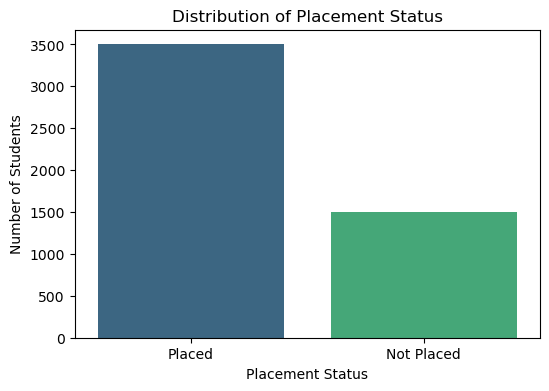

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Placement_Status',
    data=df,
    palette='viridis'
)

plt.title('Distribution of Placement Status')
plt.xlabel('Placement Status')
plt.ylabel('Number of Students')

plt.show()

Observation: The target variable (Placement_Status) has a distribution of approximately 70% Placed and 30% Not Placed students. 
This distribution is reasonably balanced for a classification problem, allowing the machine learning model to learn meaningful 
patterns from both classes without being overly biased toward one outcome.

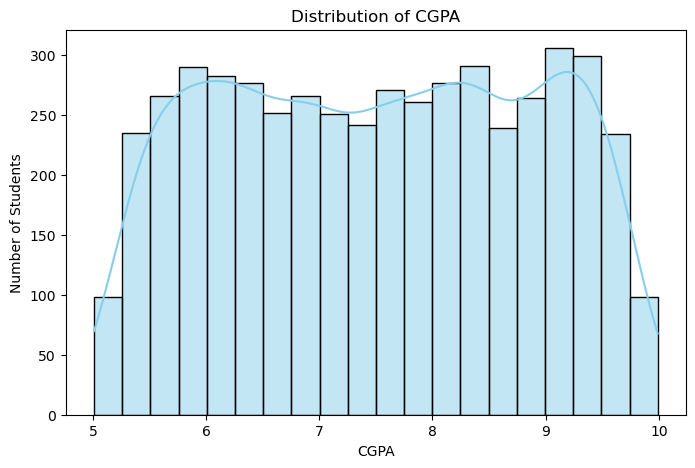

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['CGPA'],
    bins=20,
    kde=True,
    color='skyblue'
)

plt.title('Distribution of CGPA')
plt.xlabel('CGPA')
plt.ylabel('Number of Students')

plt.show()

Observation: The CGPA distribution is fairly evenly spread across the dataset rather than following a perfect normal distribution.

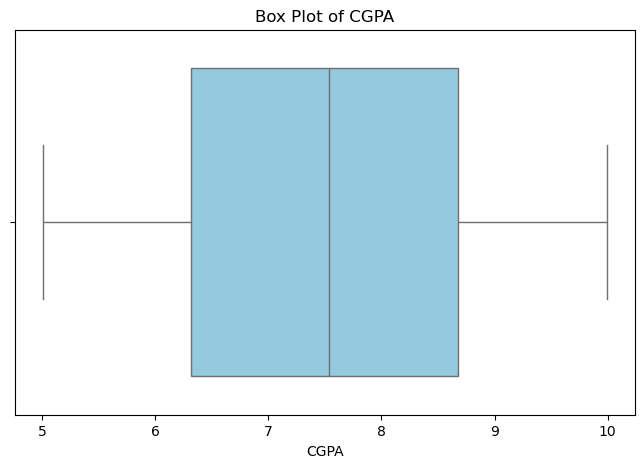

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['CGPA'],
    color='skyblue'
)

plt.title("Box Plot of CGPA")
plt.xlabel("CGPA")

plt.show()

Observation: The CGPA values range from approximately 5.0 to 10.0, with a median around 7.5. The middle 50% of students have CGPA values between 6.3 
and 8.7. No significant outliers are observed, indicating a clean and well-distributed feature suitable for model training.

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7868\1803107488.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


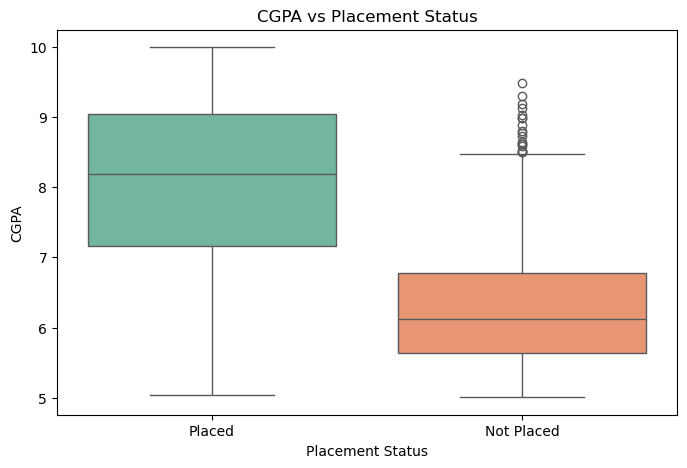

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Placement_Status',
    y='CGPA',
    data=df,
    palette='Set2'
)

plt.title('CGPA vs Placement Status')
plt.xlabel('Placement Status')
plt.ylabel('CGPA')

plt.show()

Observation: The box plot shows that placed students generally have significantly higher CGPA values than not placed students. 
The median CGPA of placed students is around 8.2, whereas the median for not placed students is around 6.1. A few students with 
high CGPA were still not placed, indicating that placement decisions are influenced by multiple factors beyond academic performance.

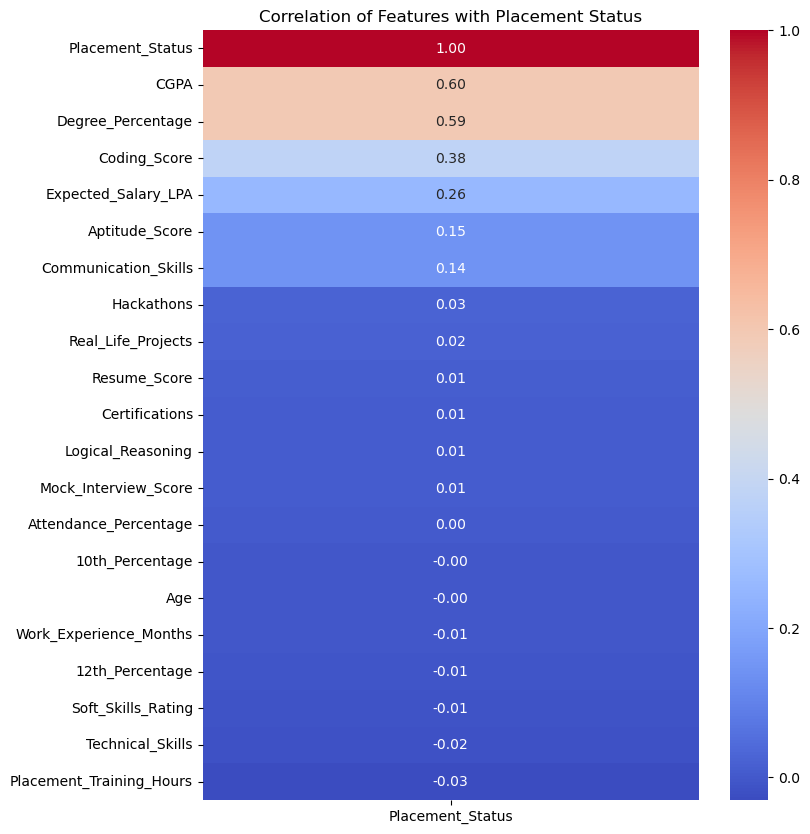

In [19]:
# Correlation of all numerical features with Placement_Status
df_corr = df.copy()

df_corr["Placement_Status"] = df_corr["Placement_Status"].map({
    "Placed": 1,
    "Not Placed": 0
})

corr_matrix = df_corr.corr(numeric_only=True)


placement_corr = (
    corr_matrix["Placement_Status"]
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,10))

sns.heatmap(
    placement_corr.to_frame(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation of Features with Placement Status")

plt.show()

Observation: The correlation analysis shows that CGPA (0.60) and Degree Percentage (0.59) have the strongest positive relationship with placement 
status, followed by Coding Score (0.38). These findings suggest that academic performance and technical competency are the most influential factors 
in predicting student placement. Most other features exhibit weak correlations, indicating that they have a limited individual linear relationship 
with placement outcomes.

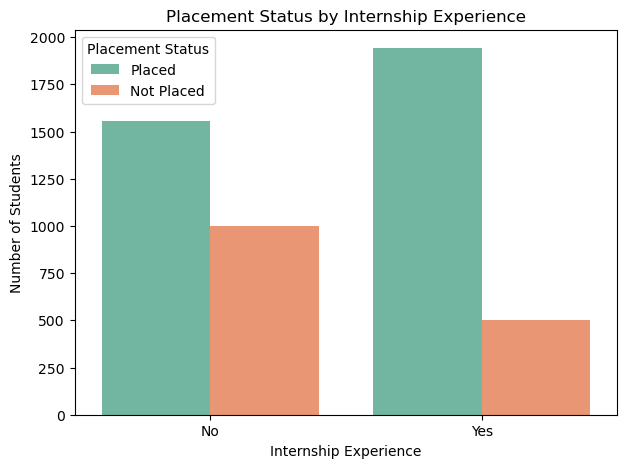

In [20]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='Internship_Experience',
    hue='Placement_Status',
    data=df,
    palette='Set2'
)

plt.title('Placement Status by Internship Experience')
plt.xlabel('Internship Experience')
plt.ylabel('Number of Students')

plt.legend(title='Placement Status')

plt.show()

Observation: Students with internship experience exhibit a significantly higher placement rate compared to those without internships. The majority 
of students who completed internships were successfully placed, whereas students without internship experience had a comparatively larger proportion 
of non-placements. This indicates that internship experience is an important factor contributing to employability.

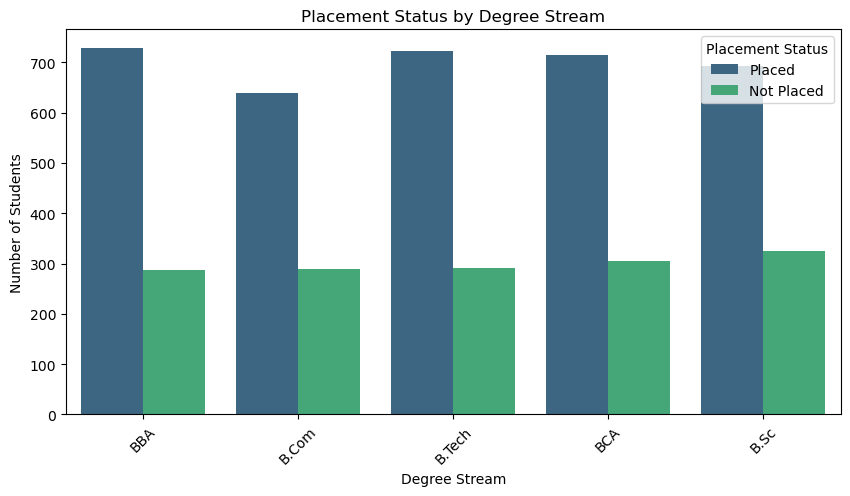

In [21]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='Degree_Stream',
    hue='Placement_Status',
    data=df,
    palette='viridis'
)

plt.title('Placement Status by Degree Stream')
plt.xlabel('Degree Stream')
plt.ylabel('Number of Students')

plt.xticks(rotation=45)
plt.legend(title='Placement Status')

plt.show()

Observation: The placement analysis across different degree streams shows that all streams have a higher number of placed students than not placed 
students. BBA and B.Tech students exhibit the highest placement counts, while B.Com has the lowest. However, the overall differences between degree 
streams are relatively small, indicating that academic performance, technical skills, and internship experience are likely stronger predictors of 
placement than the degree stream itself.

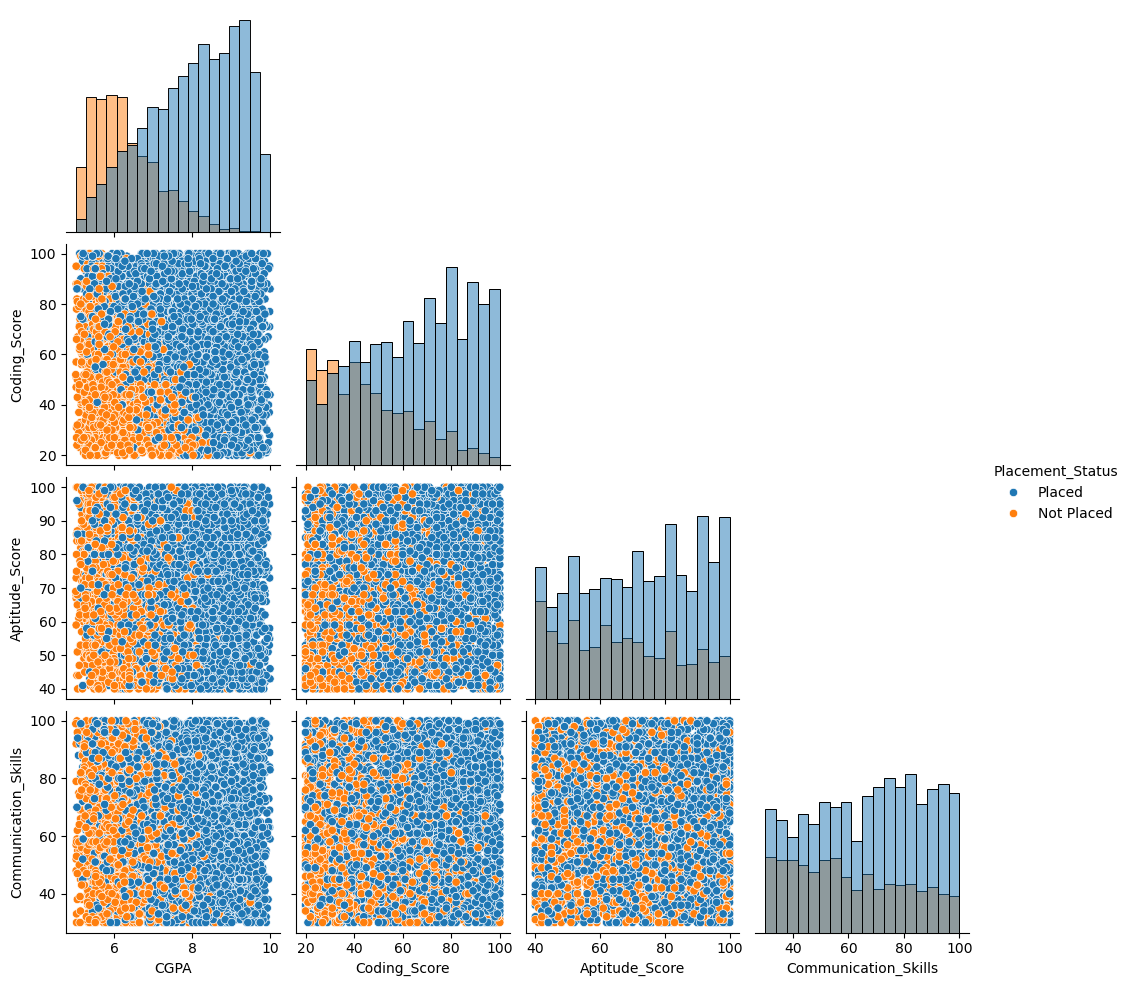

In [22]:
top_features = [
    'CGPA',
    'Coding_Score',
    'Aptitude_Score',
    'Communication_Skills',
    'Placement_Status'
]

sns.pairplot(
    df[top_features],
    hue='Placement_Status',
    diag_kind='hist',
    corner=True
)

plt.show()

Observation: The pair plot indicates that students with higher CGPA and Coding Scores are more likely to be placed. While Aptitude Score and 
Communication Skills also contribute positively, they exhibit greater overlap between the placed and not placed groups. Overall, the pair plot 
suggests that placement outcomes are influenced by a combination of academic performance and technical competencies rather than a single feature.

In [23]:
# Separate features and target variable
X = df.drop("Placement_Status", axis=1)
y = df["Placement_Status"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (5000, 30)
Target Shape: (5000,)


In [24]:
# Numerical columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['Age', '10th_Percentage', '12th_Percentage', 'Degree_Percentage',
       'CGPA', 'Aptitude_Score', 'Coding_Score', 'Communication_Skills',
       'Technical_Skills', 'Logical_Reasoning', 'Soft_Skills_Rating',
       'Real_Life_Projects', 'Work_Experience_Months', 'Certifications',
       'Hackathons', 'Attendance_Percentage', 'Mock_Interview_Score',
       'Resume_Score', 'Placement_Training_Hours', 'Expected_Salary_LPA'],
      dtype='object')

Categorical Columns:
Index(['Student_ID', 'Student_Name', 'Gender', 'State', 'Degree_Stream',
       'Specialization', 'Internship_Experience', 'Leadership',
       'Extracurricular', 'English_Proficiency'],
      dtype='object')


In [25]:
X = X.drop(['Student_ID', 'Student_Name'], axis=1)

print(X.shape)

(5000, 28)


In [26]:
numerical_cols = X.select_dtypes(include=['int64','float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

print(categorical_cols)

Index(['Gender', 'State', 'Degree_Stream', 'Specialization',
       'Internship_Experience', 'Leadership', 'Extracurricular',
       'English_Proficiency'],
      dtype='object')


In [27]:
binary_cols = [
    'Gender',
    'Internship_Experience',
    'Leadership',
    'Extracurricular'
]

In [28]:
ordinal_cols = [
    'English_Proficiency'
]

In [29]:
nominal_cols = [
    'State',
    'Degree_Stream',
    'Specialization'
]

In [30]:
print(df["English_Proficiency"].unique())

['Average' 'Poor' 'Excellent' 'Good']


In [31]:
binary_transformer = OneHotEncoder(drop='if_binary')

In [32]:
ordinal_transformer = OrdinalEncoder(
    categories=[
        ['Poor', 'Average', 'Good', 'Excellent']
    ]
)

In [33]:
nominal_transformer = OneHotEncoder(
    handle_unknown='ignore'
)

In [34]:
numeric_transformer = StandardScaler()

In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),

        ('binary', binary_transformer, binary_cols),

        ('ordinal', ordinal_transformer, ordinal_cols),

        ('nominal', nominal_transformer, nominal_cols)
    ]
)

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [37]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [38]:
print("Training Shape :", X_train_processed.shape)
print("Testing Shape  :", X_test_processed.shape)

Training Shape : (4000, 53)
Testing Shape  : (1000, 53)


Model 1 - Logistic Regression

In [39]:
# Create the model
log_model = LogisticRegression(random_state=42, max_iter=1000)

# Train
log_model.fit(X_train_processed, y_train)

# Predict
y_pred = log_model.predict(X_test_processed)

In [40]:
print("========== Logistic Regression ==========")
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred, pos_label='Placed'):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred, pos_label='Placed'):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred, pos_label='Placed'):.4f}")

========== Logistic Regression ==========
Accuracy  : 0.9620
Precision : 0.9742
Recall    : 0.9714
F1 Score  : 0.9728


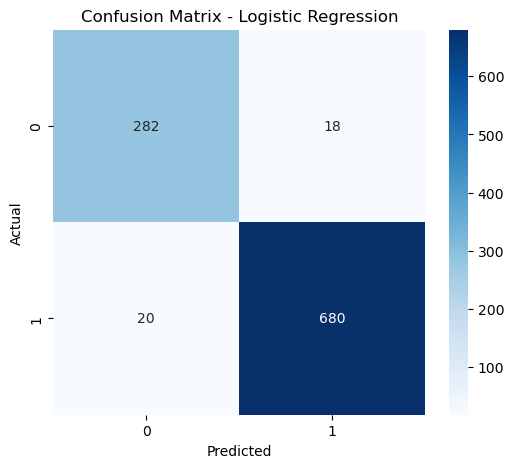

In [41]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

The Logistic Regression model achieved an accuracy of 96.2%, indicating excellent predictive performance on the test dataset. The model correctly classified 282 Not Placed students and 680 Placed students, while misclassifying only 38 students out of 1000 test samples. The high precision (97.42%) indicates that when the model predicts a student will be placed, it is usually correct. Similarly, the recall (97.14%) shows that the model successfully identifies most students who are actually placed. Overall, Logistic Regression provides a strong baseline model for student placement prediction.

Model 2 - Decision Tree

In [42]:
# Create Decision Tree model
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=10
)

# Train the model
dt_model.fit(X_train_processed, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test_processed)

In [43]:
print("========== Decision Tree ==========")

print(f"Accuracy  : {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_dt, pos_label='Placed'):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_dt, pos_label='Placed'):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_dt, pos_label='Placed'):.4f}")

========== Decision Tree ==========
Accuracy  : 0.9070
Precision : 0.9269
Recall    : 0.9414
F1 Score  : 0.9341


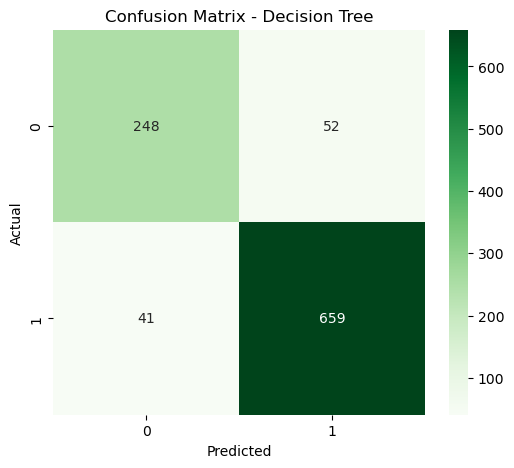

In [44]:
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")

plt.show()

In [45]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

  Not Placed       0.86      0.83      0.84       300
      Placed       0.93      0.94      0.93       700

    accuracy                           0.91      1000
   macro avg       0.89      0.88      0.89      1000
weighted avg       0.91      0.91      0.91      1000



The Decision Tree classifier achieved an accuracy of 90.7% on the test dataset. It correctly classified 907 out of 1000 students. 
Although the model demonstrated good predictive capability, its performance was lower than the Logistic Regression model. The 
confusion matrix shows that the Decision Tree made more misclassifications, particularly by predicting some not placed students 
as placed. This indicates that the model may have learned patterns specific to the training data and is slightly prone to overfitting.

Model 3 - RandomForrest

In [46]:
# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train_processed, y_train)

# Predict on test data
y_pred_rf = rf_model.predict(X_test_processed)

In [47]:
print("========== Random Forest ==========")

print(f"Accuracy  : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_rf, pos_label='Placed'):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_rf, pos_label='Placed'):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_rf, pos_label='Placed'):.4f}")

========== Random Forest ==========
Accuracy  : 0.9350
Precision : 0.9416
Recall    : 0.9671
F1 Score  : 0.9542


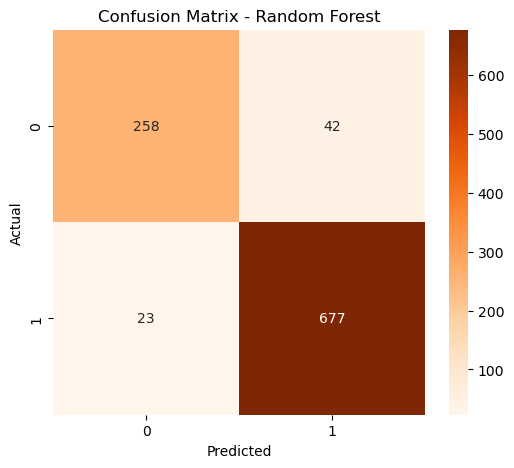

In [48]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

In [49]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

  Not Placed       0.92      0.86      0.89       300
      Placed       0.94      0.97      0.95       700

    accuracy                           0.94      1000
   macro avg       0.93      0.91      0.92      1000
weighted avg       0.93      0.94      0.93      1000



The Random Forest classifier achieved an accuracy of 93.5% on the test dataset. The model correctly classified 935 out of 1000 students.
Compared with the Decision Tree model, Random Forest significantly improved accuracy and reduced the number of incorrect classifications 
by combining predictions from multiple decision trees. The model achieved high recall, indicating that it successfully identified most 
students who were actually placed. Overall, Random Forest is a robust and reliable classification model for student placement prediction.

In [50]:
comparison = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    
    "Precision": [
        precision_score(y_test, y_pred, pos_label="Placed"),
        precision_score(y_test, y_pred_dt, pos_label="Placed"),
        precision_score(y_test, y_pred_rf, pos_label="Placed")
    ],
    
    "Recall": [
        recall_score(y_test, y_pred, pos_label="Placed"),
        recall_score(y_test, y_pred_dt, pos_label="Placed"),
        recall_score(y_test, y_pred_rf, pos_label="Placed")
    ],
    
    "F1 Score": [
        f1_score(y_test, y_pred, pos_label="Placed"),
        f1_score(y_test, y_pred_dt, pos_label="Placed"),
        f1_score(y_test, y_pred_rf, pos_label="Placed")
    ]
}

comparison_df = pd.DataFrame(comparison)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.962,0.974212,0.971429,0.972818
1,Decision Tree,0.907,0.926864,0.941429,0.934089
2,Random Forest,0.935,0.941586,0.967143,0.954193


In [51]:
comparison_df.iloc[:,1:] = comparison_df.iloc[:,1:].round(4)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.962,0.9742,0.9714,0.9728
1,Decision Tree,0.907,0.9269,0.9414,0.9341
2,Random Forest,0.935,0.9416,0.9671,0.9542


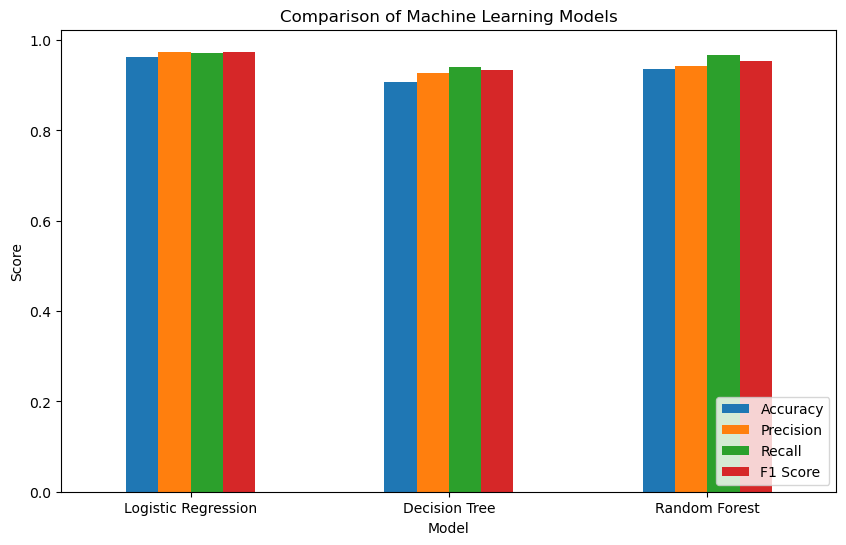

In [52]:
import matplotlib.pyplot as plt

comparison_df.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Comparison of Machine Learning Models")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.legend(loc="lower right")

plt.show()

Observation = Three machine learning algorithms were evaluated for predicting student placement status. Logistic Regression achieved the highest 
performance with an accuracy of 96.2%, followed by Random Forest (93.5%) and Decision Tree (90.7%). Logistic Regression also obtained the best 
Precision, Recall, and F1-Score, indicating consistent and reliable classification performance. Based on these evaluation metrics, Logistic 
Regression was selected as the final model for predicting student placement.

Logistic Regression was selected because it achieved the highest values across all evaluation metrics. The synthetic dataset exhibits relationships 
that are largely linear between student characteristics (such as CGPA, Coding Score, Internship Experience) and placement status, making Logistic 
Regression well suited to this prediction task. In addition, it is computationally efficient, interpretable, and less prone to overfitting than 
Decision Trees.

In [53]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'penalty': ['l2']
}

In [54]:
grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [55]:
grid_search.fit(X_train_processed, y_train)

,estimator,LogisticRegre...ndom_state=42)
,param_grid,"{'C': [0.01, 0.1, ...], 'penalty': ['l2'], 'solver': ['liblinear', 'lbfgs']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [56]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}

Best Cross Validation Accuracy:
0.954


In [57]:
best_model = grid_search.best_estimator_

In [58]:
y_pred_best = best_model.predict(X_test_processed)

In [59]:
print("========== Optimized Logistic Regression ==========")

print(f"Accuracy  : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_best, pos_label='Placed'):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_best, pos_label='Placed'):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_best, pos_label='Placed'):.4f}")

========== Optimized Logistic Regression ==========
Accuracy  : 0.9580
Precision : 0.9673
Recall    : 0.9729
F1 Score  : 0.9701


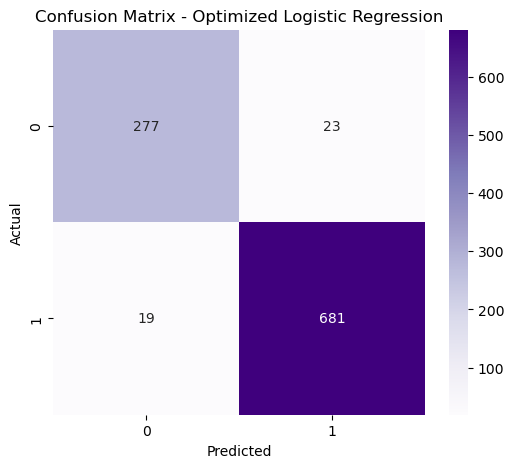

In [60]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Optimized Logistic Regression")

plt.show()

In [61]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Optimized Logistic Regression"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_best)
    ],
    "Precision": [
        precision_score(y_test, y_pred, pos_label="Placed"),
        precision_score(y_test, y_pred_best, pos_label="Placed")
    ],
    "Recall": [
        recall_score(y_test, y_pred, pos_label="Placed"),
        recall_score(y_test, y_pred_best, pos_label="Placed")
    ],
    "F1 Score": [
        f1_score(y_test, y_pred, pos_label="Placed"),
        f1_score(y_test, y_pred_best, pos_label="Placed")
    ]
})

comparison.iloc[:, 1:] = comparison.iloc[:, 1:].round(4)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.962,0.9742,0.9714,0.9728
1,Optimized Logistic Regression,0.958,0.9673,0.9729,0.9701


Hyperparameter tuning was performed using GridSearchCV to optimize the Logistic Regression model. Different values of the regularization parameter (C) 
and optimization solver were evaluated using 5-fold cross-validation. The optimized model achieved performance very close to the baseline model. While 
recall improved slightly, the original Logistic Regression model produced higher accuracy, precision, and F1-score on the test dataset. Therefore, the 
original Logistic Regression model was selected as the final model for student placement prediction.

In [62]:
import joblib

joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']

In [63]:
joblib.dump(log_model, "placement_model.pkl")

['placement_model.pkl']

In [64]:
import os
print(os.getcwd())

C:\Users\lenovo\Student_Placement


In [66]:
preprocessor.transformers

[('num',
  StandardScaler(),
  Index(['Age', '10th_Percentage', '12th_Percentage', 'Degree_Percentage',
         'CGPA', 'Aptitude_Score', 'Coding_Score', 'Communication_Skills',
         'Technical_Skills', 'Logical_Reasoning', 'Soft_Skills_Rating',
         'Real_Life_Projects', 'Work_Experience_Months', 'Certifications',
         'Hackathons', 'Attendance_Percentage', 'Mock_Interview_Score',
         'Resume_Score', 'Placement_Training_Hours', 'Expected_Salary_LPA'],
        dtype='object')),
 ('binary',
  OneHotEncoder(drop='if_binary'),
  ['Gender', 'Internship_Experience', 'Leadership', 'Extracurricular']),
 ('ordinal',
  OrdinalEncoder(categories=[['Poor', 'Average', 'Good', 'Excellent']]),
  ['English_Proficiency']),
 ('nominal',
  OneHotEncoder(handle_unknown='ignore'),
  ['State', 'Degree_Stream', 'Specialization'])]

In [67]:
preprocessor.named_transformers_["binary"].categories_

[array(['Female', 'Male'], dtype=object),
 array(['No', 'Yes'], dtype=object),
 array(['No', 'Yes'], dtype=object),
 array(['Coding Club', 'Cultural', 'NSS', 'Sports', nan], dtype=object)]

In [68]:
print(df["Internship_Experience"].unique())
print(df["Leadership"].unique())
print(df["Extracurricular"].unique())

['No' 'Yes']
['No' 'Yes']
['Cultural' nan 'NSS' 'Sports' 'Coding Club']


In [70]:
print(preprocessor.get_feature_names_out())

['num__Age' 'num__10th_Percentage' 'num__12th_Percentage'
 'num__Degree_Percentage' 'num__CGPA' 'num__Aptitude_Score'
 'num__Coding_Score' 'num__Communication_Skills' 'num__Technical_Skills'
 'num__Logical_Reasoning' 'num__Soft_Skills_Rating'
 'num__Real_Life_Projects' 'num__Work_Experience_Months'
 'num__Certifications' 'num__Hackathons' 'num__Attendance_Percentage'
 'num__Mock_Interview_Score' 'num__Resume_Score'
 'num__Placement_Training_Hours' 'num__Expected_Salary_LPA'
 'binary__Gender_Male' 'binary__Internship_Experience_Yes'
 'binary__Leadership_Yes' 'binary__Extracurricular_Coding Club'
 'binary__Extracurricular_Cultural' 'binary__Extracurricular_NSS'
 'binary__Extracurricular_Sports' 'binary__Extracurricular_nan'
 'ordinal__English_Proficiency' 'nominal__State_DL' 'nominal__State_GJ'
 'nominal__State_KA' 'nominal__State_MH' 'nominal__State_MP'
 'nominal__State_PB' 'nominal__State_RJ' 'nominal__State_TN'
 'nominal__State_UP' 'nominal__State_WB' 'nominal__Degree_Stream_B.Com'
 '